In [ ]:
# Import các thư viện
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

%matplotlib inline

In [ ]:
# Đọc file CSV và lưu thành DataFrame
weather_df = pd.read_csv('kanpur.csv', parse_dates=['date_time'], index_col='date_time', on_bad_lines='skip')
weather_df.head(5)

,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,sunrise,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
date_time,,,,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,24,10,0.0,8.7,4,1,31,09:56 AM,09:45 PM,06:57 AM,...,11,21,17,50,0.0,1015,11,10,320,10
2009-01-01 01:00:00,24,10,0.0,8.7,4,1,31,09:56 AM,09:45 PM,06:57 AM,...,12,22,11,52,0.0,1015,11,10,315,11
2009-01-01 02:00:00,24,10,0.0,8.7,4,1,31,09:56 AM,09:45 PM,06:57 AM,...,12,23,6,55,0.0,1015,11,10,310,11
2009-01-01 03:00:00,24,10,0.0,8.7,4,1,31,09:56 AM,09:45 PM,06:57 AM,...,12,23,0,57,0.0,1015,10,10,304,12
2009-01-01 04:00:00,24,10,0.0,8.7,4,1,31,09:56 AM,09:45 PM,06:57 AM,...,14,19,0,54,0.0,1016,11,10,302,11


In [ ]:
# kiểm tra các cột trong dataframe
weather_df.columns

Index(['maxtempC', 'mintempC', 'totalSnow_cm', 'sunHour', 'uvIndex',
       'uvIndex.1', 'moon_illumination', 'moonrise', 'moonset', 'sunrise',
       'sunset', 'DewPointC', 'FeelsLikeC', 'HeatIndexC', 'WindChillC',
       'WindGustKmph', 'cloudcover', 'humidity', 'precipMM', 'pressure',
       'tempC', 'visibility', 'winddirDegree', 'windspeedKmph'],
      dtype='object')

In [ ]:
# kiểm tra kích thước
weather_df.shape

(96432, 24)

In [ ]:
weather_df.describe()

,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,DewPointC,FeelsLikeC,HeatIndexC,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
count,96432.000000,96432.000000,96432.0,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.00000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000,96432.000000
mean,33.400199,22.374564,0.0,11.037805,6.877053,4.465012,46.094077,13.230629,30.735783,30.86884,29.088384,14.211766,16.993550,44.370479,0.037756,1006.217946,27.429577,9.885214,205.537270,9.734092
std,6.994211,7.635253,0.0,2.152973,1.551294,3.414374,31.249725,8.053778,9.320398,9.17754,8.051981,6.926605,23.150025,22.484991,0.307143,7.593850,8.459575,1.058515,104.369548,4.835331
min,15.000000,3.000000,0.0,4.000000,3.000000,1.000000,0.000000,-14.000000,4.000000,7.00000,4.000000,0.000000,0.000000,2.000000,0.000000,986.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,16.000000,0.0,8.700000,6.000000,1.000000,18.000000,7.000000,24.000000,25.00000,24.000000,9.000000,0.000000,26.000000,0.000000,1000.000000,21.000000,10.000000,101.000000,6.000000
50%,34.000000,24.000000,0.0,11.600000,7.000000,5.000000,46.000000,12.000000,31.000000,31.00000,29.000000,14.000000,5.000000,42.000000,0.000000,1006.000000,28.000000,10.000000,240.000000,9.000000
75%,38.000000,28.000000,0.0,13.000000,8.000000,8.000000,73.000000,21.000000,38.000000,38.00000,35.000000,18.000000,27.000000,61.000000,0.000000,1013.000000,33.000000,10.000000,299.000000,12.000000
max,51.000000,39.000000,0.0,13.900000,11.000000,11.000000,100.000000,31.000000,65.000000,65.00000,54.000000,75.000000,100.000000,100.000000,20.600000,1024.000000,50.000000,20.000000,360.000000,47.000000


In [ ]:
# kiểm tra xem trong dữ liệu (dataset) có giá trị null (giá trị thiếu) hay không
weather_df.isnull().any()

,0
maxtempC,False
mintempC,False
totalSnow_cm,False
sunHour,False
uvIndex,False
uvIndex.1,False
moon_illumination,False
moonrise,False
moonset,False
sunrise,False


In [ ]:
# tách biến đặc trưng (feature) cần dự đoán (ví dụ là nhiệt độ - temperature) ra khỏi các biến đặc trưng còn lại
weather_df_num=weather_df.loc[:,['maxtempC','mintempC','cloudcover','humidity','tempC', 'sunHour','HeatIndexC', 'precipMM', 'pressure','windspeedKmph']]
weather_df_num.head()

,maxtempC,mintempC,cloudcover,humidity,tempC,sunHour,HeatIndexC,precipMM,pressure,windspeedKmph
date_time,,,,,,,,,,
2009-01-01 00:00:00,24,10,17,50,11,8.7,12,0.0,1015,10
2009-01-01 01:00:00,24,10,11,52,11,8.7,13,0.0,1015,11
2009-01-01 02:00:00,24,10,6,55,11,8.7,13,0.0,1015,11
2009-01-01 03:00:00,24,10,0,57,10,8.7,13,0.0,1015,12
2009-01-01 04:00:00,24,10,0,54,11,8.7,14,0.0,1016,11


In [ ]:
# kích thước (số dòng và số cột) của dataframe mới
weather_df_num.shape

(96432, 10)

In [ ]:
# các cột có trong dataframe mới
weather_df_num.columns

Index(['maxtempC', 'mintempC', 'cloudcover', 'humidity', 'tempC', 'sunHour',
       'HeatIndexC', 'precipMM', 'pressure', 'windspeedKmph'],
      dtype='object')

array([<Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>],
      dtype=object)

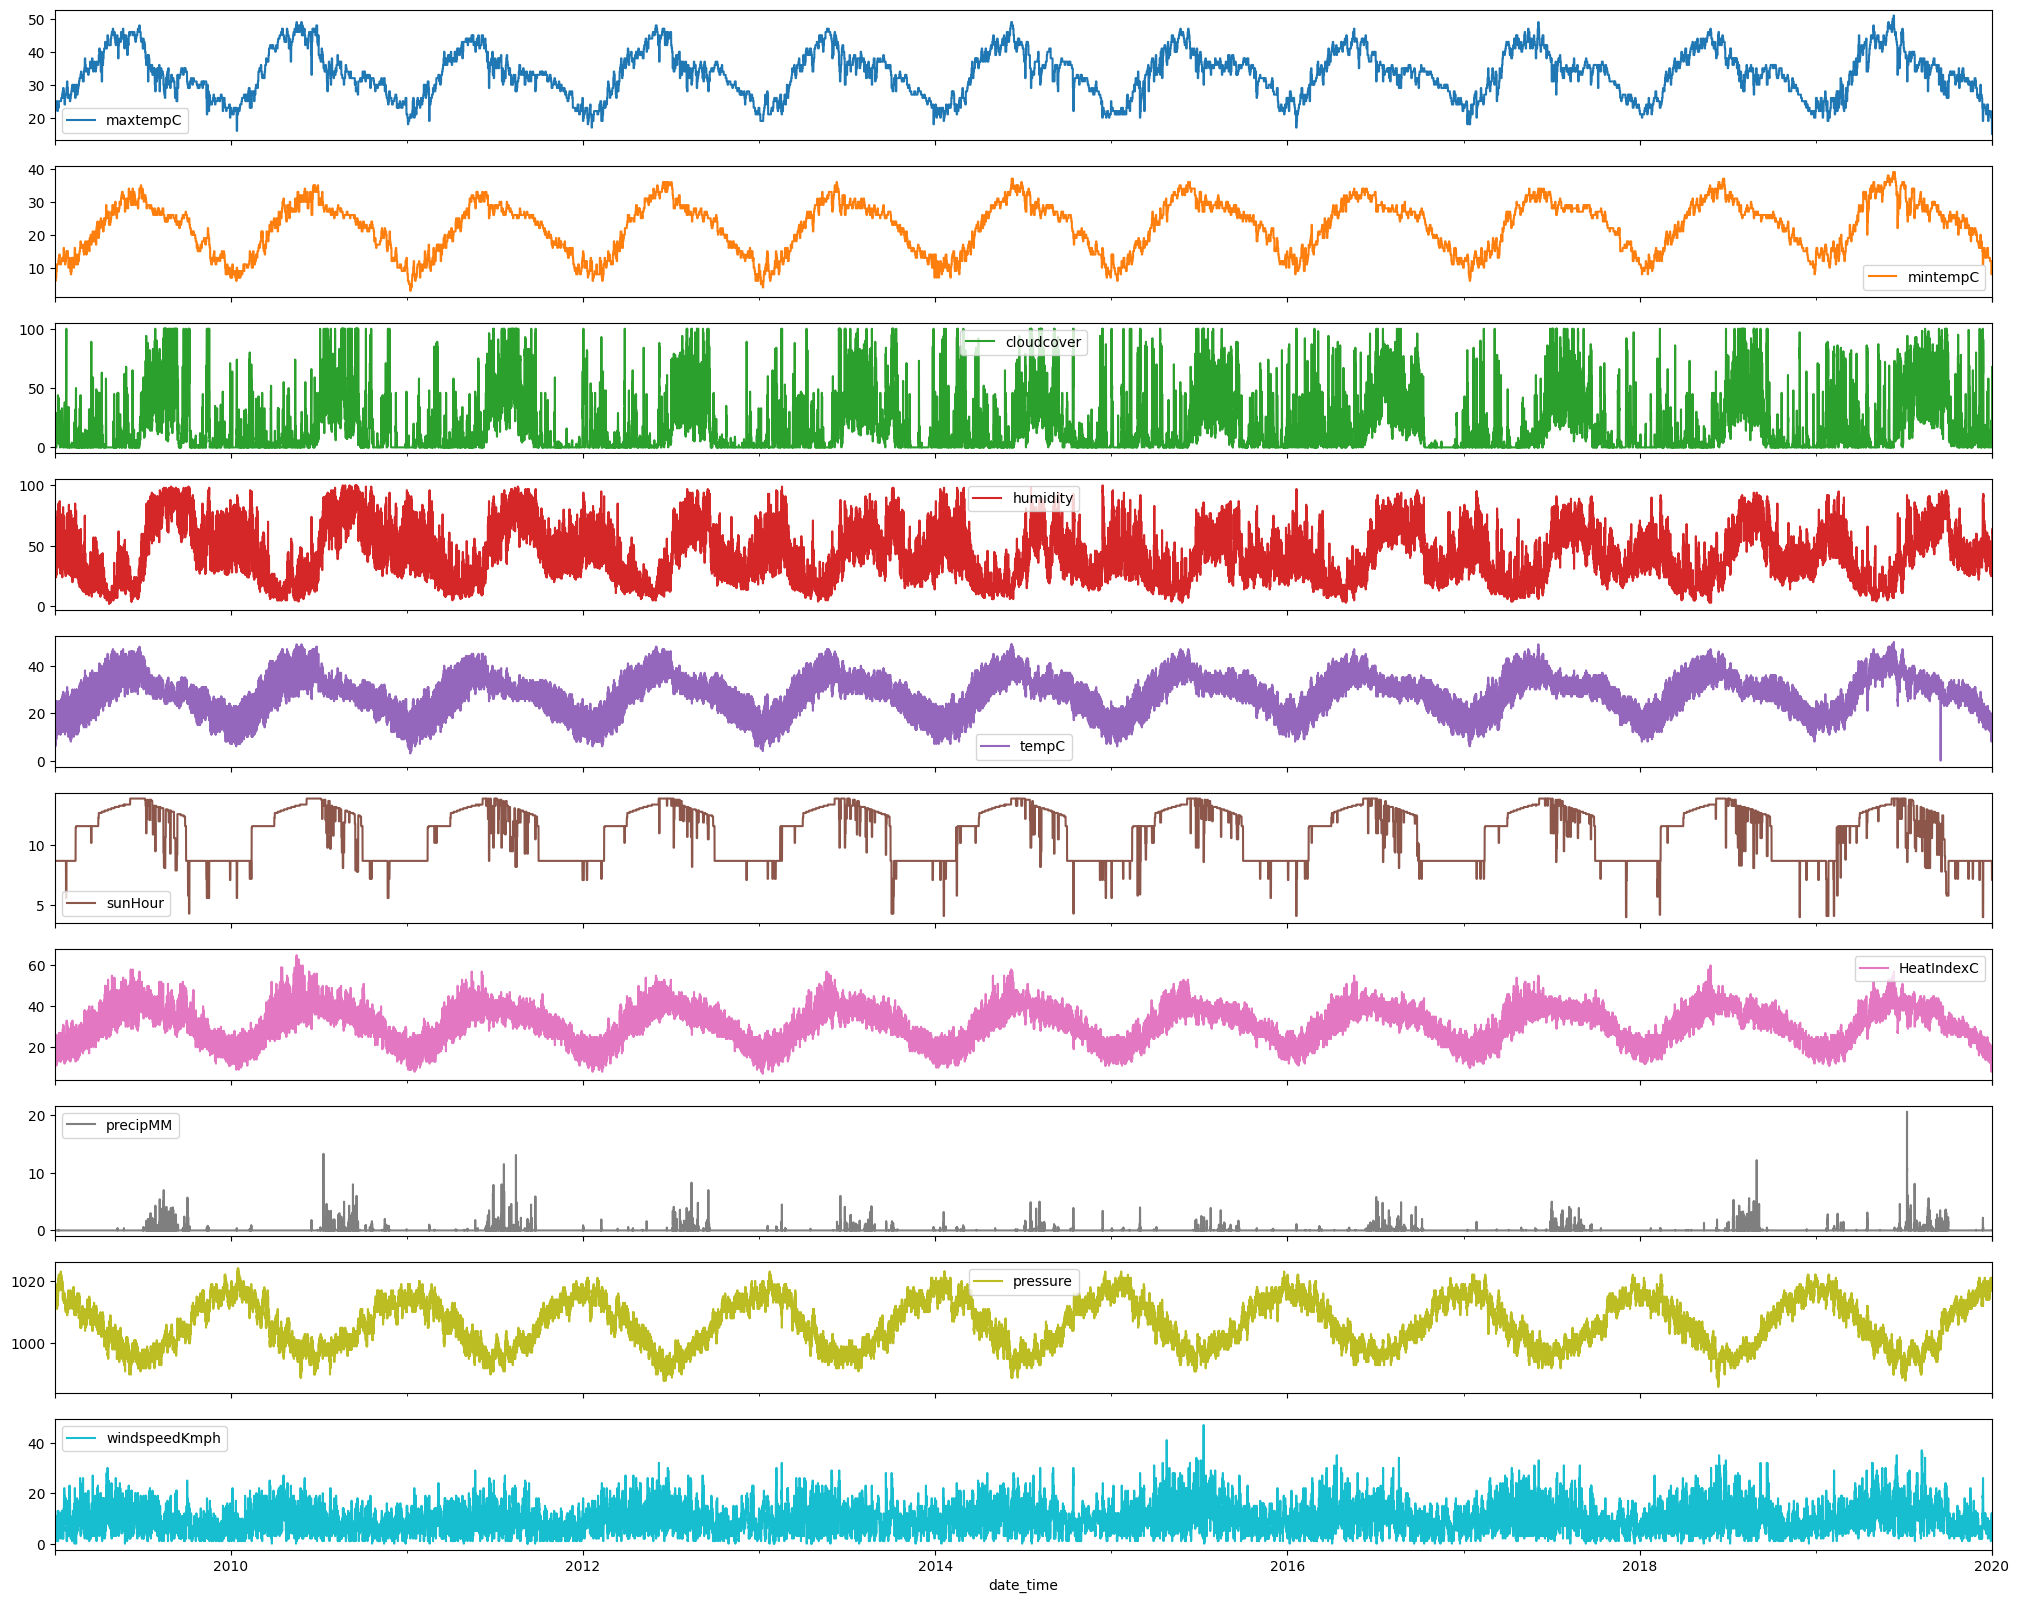

In [ ]:
# vẽ biểu đồ cho tất cả các giá trị của các cột trong dataframe
weather_df_num.plot(subplots=True, figsize=(25,20))

array([<Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>,
       <Axes: xlabel='date_time'>, <Axes: xlabel='date_time'>],
      dtype=object)

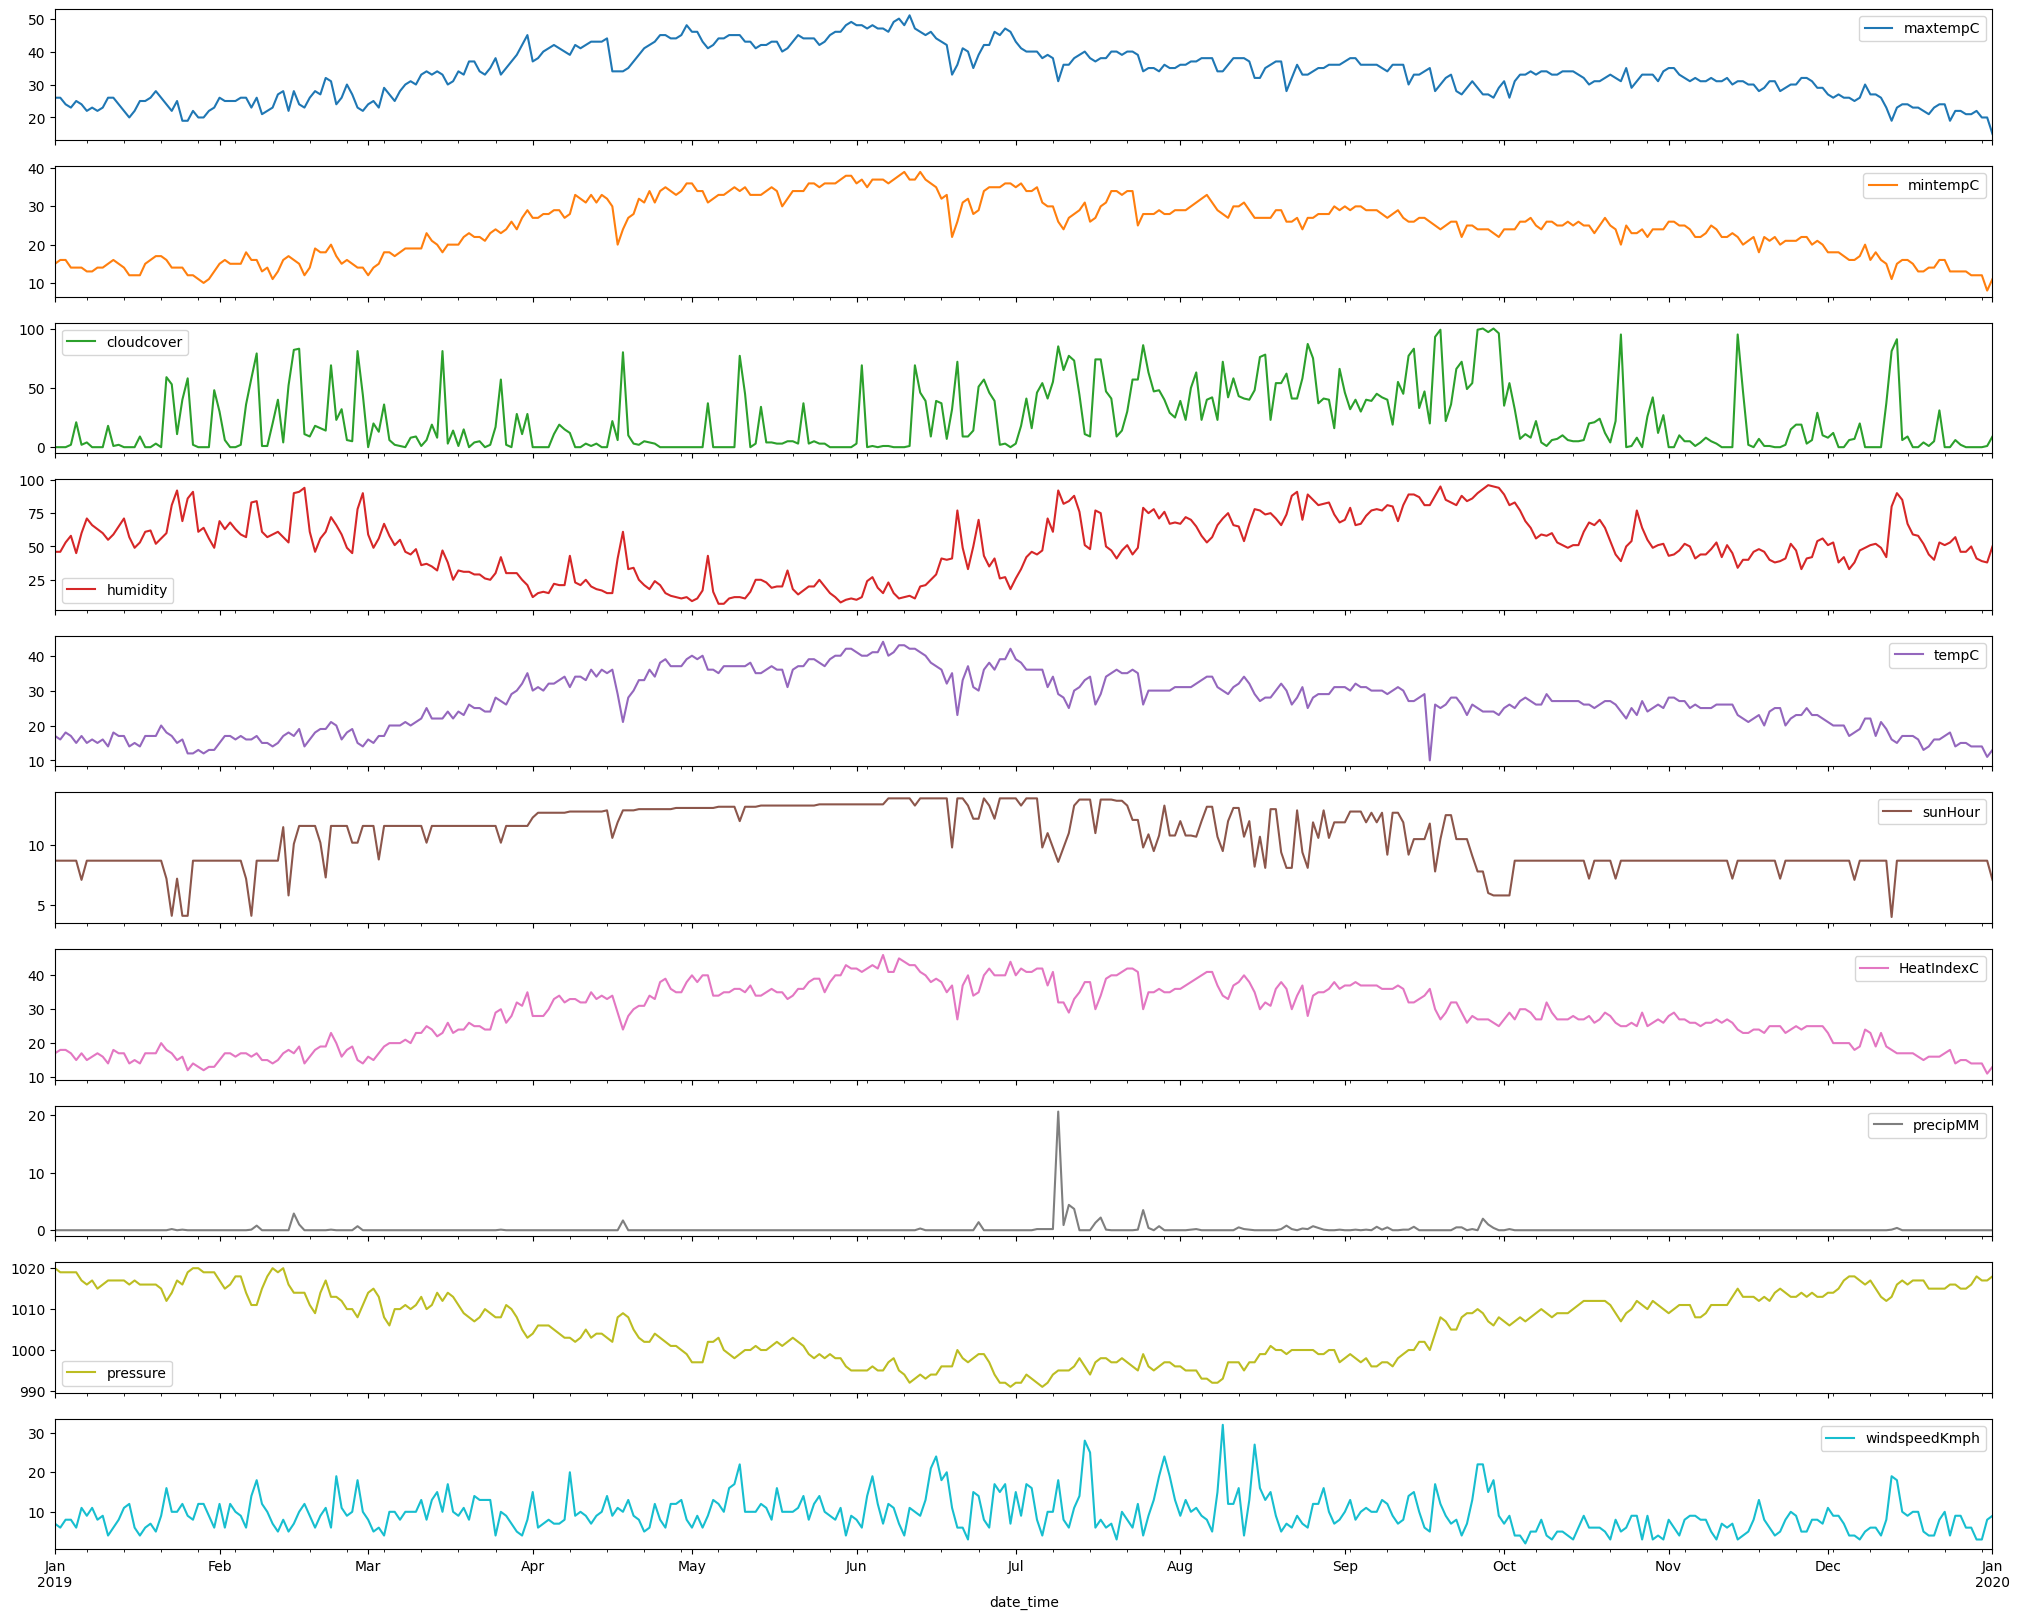

In [ ]:
# vẽ biểu đồ tất cả các giá trị của các cột trong dataframe, nhưng chỉ lấy dữ liệu trong 1 năm
weather_df_num['2019':'2020'].resample('D').fillna(method='pad').plot(subplots=True, figsize=(25,20))

array([[<Axes: title={'center': 'maxtempC'}>,
        <Axes: title={'center': 'mintempC'}>,
        <Axes: title={'center': 'cloudcover'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'tempC'}>,
        <Axes: title={'center': 'sunHour'}>],
       [<Axes: title={'center': 'HeatIndexC'}>,
        <Axes: title={'center': 'precipMM'}>,
        <Axes: title={'center': 'pressure'}>],
       [<Axes: title={'center': 'windspeedKmph'}>, <Axes: >, <Axes: >]],
      dtype=object)

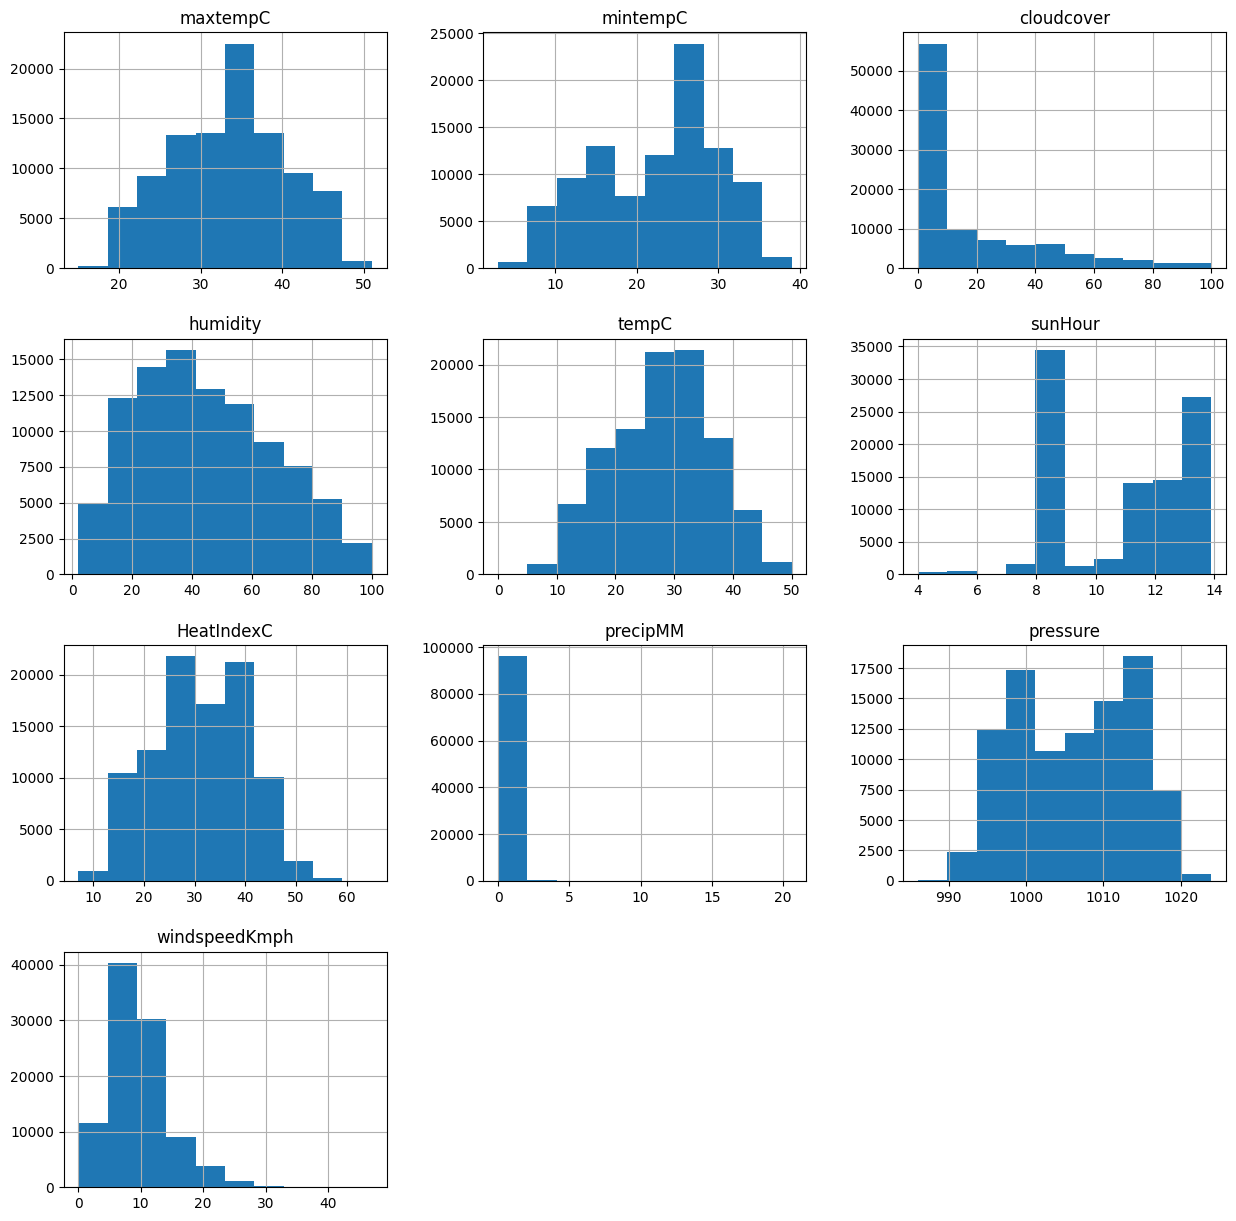

In [ ]:
weather_df_num.hist(bins=10,figsize=(15,15))

In [ ]:
weth=weather_df_num['2019':'2020']
weth.head()

,maxtempC,mintempC,cloudcover,humidity,tempC,sunHour,HeatIndexC,precipMM,pressure,windspeedKmph
date_time,,,,,,,,,,
2019-01-01 00:00:00,26,15,0,46,17,8.7,17,0.0,1020,7
2019-01-01 01:00:00,26,15,0,46,17,8.7,17,0.0,1019,7
2019-01-01 02:00:00,26,15,0,47,16,8.7,16,0.0,1019,7
2019-01-01 03:00:00,26,15,0,48,16,8.7,16,0.0,1019,6
2019-01-01 04:00:00,26,15,0,48,16,8.7,16,0.0,1019,6


In [ ]:
weather_y=weather_df_num.pop("tempC")
weather_x=weather_df_num

In [ ]:
# chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (testing set)
train_X,test_X,train_y,test_y=train_test_split(weather_x,weather_y,test_size=0.2,random_state=4)

In [ ]:
train_X.shape

(77145, 9)

In [ ]:
train_y.shape

(77145,)

In [ ]:
# train_x chứa tất cả các biến đặc trưng (features) ngoại trừ nhiệt độ,
# còn train_y chứa nhiệt độ tương ứng với các biến đó.
# Trong học máy có giám sát (supervised learning),
# ta sẽ đưa cho mô hình dữ liệu đầu vào (train_x) cùng với đầu ra đúng (train_y) để mô hình học.
# Sau đó, ta dùng dữ liệu đầu vào mới để kiểm tra xem mô hình dự đoán như thế nào.

train_y.head()

,tempC
date_time,
2012-03-13 07:00:00,22
2009-11-05 21:00:00,21
2017-10-11 22:00:00,30
2019-06-08 11:00:00,47
2019-03-06 05:00:00,18


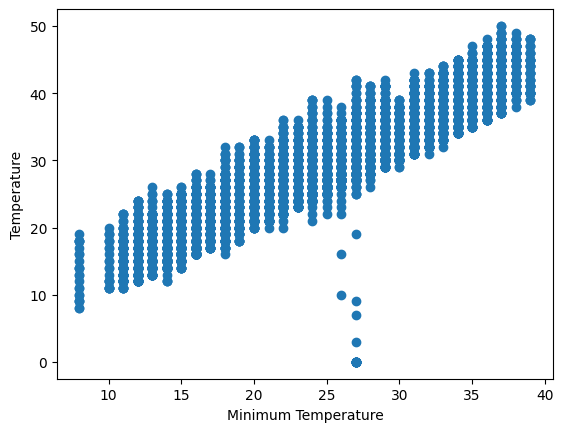

In [ ]:
# Multiple Linear Regression (Hồi quy tuyến tính đa biến)
plt.scatter(weth.mintempC, weth.tempC)
plt.xlabel("Minimum Temperature")
plt.ylabel("Temperature")
plt.show()

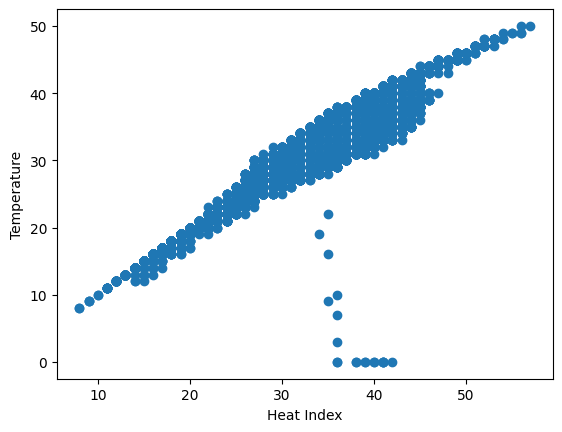

In [ ]:
# Vẽ biểu đồ scatter của HeatIndexC và tempC
plt.scatter(weth.HeatIndexC, weth.tempC)
plt.xlabel("Heat Index")
plt.ylabel("Temperature")
plt.show()

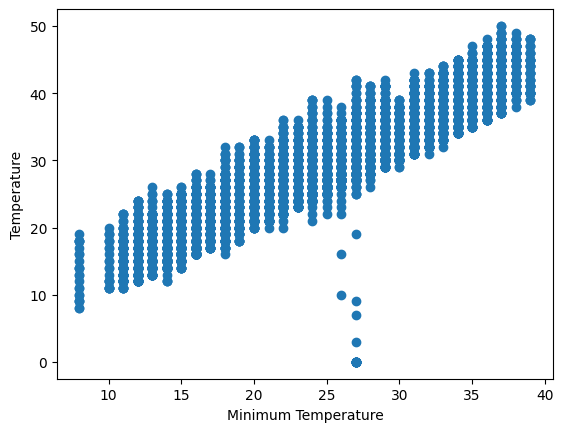

In [ ]:
# vẽ biểu đồ scatter của mintempC và tempC
plt.scatter(weth.mintempC, weth.tempC)
plt.xlabel("Minimum Temperature")
plt.ylabel("Temperature")
plt.show()

In [ ]:
# huấn luyện mô hình hồi quy tuyến tính (Linear Regression)
model=LinearRegression()
model.fit(train_X,train_y)

LinearRegression()

In [ ]:
prediction = model.predict(test_X)

In [ ]:
# giá trị trung bình của độ lớn tuyệt đối sai số dự đoán giữa prediction và test_y
np.mean(np.absolute(prediction-test_y))

np.float64(1.2004735794096797)

In [ ]:
print('Variance score: %.2f' % model.score(test_X, test_y))

Variance score: 0.96


In [ ]:
for i in range(len(prediction)):
  prediction[i]=round(prediction[i],2)
pd.DataFrame({'Actual':test_y,'Prediction':prediction,'diff':(test_y-prediction)})

,Actual,Prediction,diff
date_time,,,
2013-07-10 08:00:00,34,34.89,-0.89
2015-11-04 20:00:00,25,24.57,0.43
2015-09-21 09:00:00,34,35.08,-1.08
2017-02-16 11:00:00,28,25.22,2.78
2012-07-21 01:00:00,28,28.04,-0.04
...,...,...,...
2019-03-30 09:00:00,37,33.55,3.45
2015-11-12 12:00:00,32,30.36,1.64
2019-12-31 05:00:00,8,9.13,-1.13


In [ ]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(random_state=0)
regressor.fit(train_X,train_y)

DecisionTreeRegressor(random_state=0)

In [ ]:
prediction2=regressor.predict(test_X)
np.mean(np.absolute(prediction2-test_y))

np.float64(0.5630130830784121)

In [ ]:
print('Variance score: %.2f' % regressor.score(test_X, test_y))

Variance score: 0.98


In [ ]:
for i in range(len(prediction2)):
  prediction2[i]=round(prediction2[i],2)
pd.DataFrame({'Actual':test_y,'Prediction':prediction2,'diff':(test_y-prediction2)})

,Actual,Prediction,diff
date_time,,,
2013-07-10 08:00:00,34,34.0,0.0
2015-11-04 20:00:00,25,24.0,1.0
2015-09-21 09:00:00,34,34.0,0.0
2017-02-16 11:00:00,28,27.0,1.0
2012-07-21 01:00:00,28,28.0,0.0
...,...,...,...
2019-03-30 09:00:00,37,32.0,5.0
2015-11-12 12:00:00,32,32.0,0.0
2019-12-31 05:00:00,8,9.0,-1.0


In [ ]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
regr=RandomForestRegressor(max_depth=90,random_state=0,n_estimators=100)
regr.fit(train_X,train_y)

RandomForestRegressor(max_depth=90, random_state=0)

In [ ]:
prediction3=regr.predict(test_X)
np.mean(np.absolute(prediction3-test_y))

np.float64(0.4749165453503998)

In [ ]:
print('Variance score: %.2f' % regr.score(test_X, test_y))

Variance score: 0.99


In [ ]:
for i in range(len(prediction3)):
  prediction3[i]=round(prediction3[i],2)
pd.DataFrame({'Actual':test_y,'Prediction':prediction3,'diff':(test_y-prediction3)})

,Actual,Prediction,diff
date_time,,,
2013-07-10 08:00:00,34,33.92,0.08
2015-11-04 20:00:00,25,24.84,0.16
2015-09-21 09:00:00,34,34.25,-0.25
2017-02-16 11:00:00,28,27.00,1.00
2012-07-21 01:00:00,28,27.99,0.01
...,...,...,...
2019-03-30 09:00:00,37,32.79,4.21
2015-11-12 12:00:00,32,31.91,0.09
2019-12-31 05:00:00,8,8.81,-0.81


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
# tính hệ số xác định R² để đánh giá mức độ phù hợp của mô hình Multiple Linear Regression.
print("Mean absolute error: %.2f" % np.mean(np.absolute(prediction - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((prediction - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,prediction ) )

Mean absolute error: 1.20
Residual sum of squares (MSE): 2.51
R2-score: 0.96


In [ ]:
# tính hệ số xác định R² để đánh giá hiệu quả của mô hình Decision Tree Regression.
print("Mean absolute error: %.2f" % np.mean(np.absolute(prediction2 - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((prediction2 - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,prediction2 ) )

Mean absolute error: 0.56
Residual sum of squares (MSE): 1.12
R2-score: 0.98


In [ ]:
# tính hệ số xác định R² để đánh giá độ chính xác của mô hình Random Forest Regression.
from sklearn.metrics import r2_score

print("Mean absolute error: %.2f" % np.mean(np.absolute(prediction3 - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((prediction3 - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,prediction3 ) )

Mean absolute error: 0.47
Residual sum of squares (MSE): 0.63
R2-score: 0.99


In [ ]:
# Chọn mô hình để tối ưu
model_to_tune = GradientBoostingRegressor(random_state=42)

# Định nghĩa lưới siêu tham số để GridSearchCV thử nghiệm
param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

print(f"Lưới siêu tham số sẽ được tìm kiếm cho {model_to_tune.__class__.__name__}:")
for param, values in param_grid_gbr.items():
    print(f"  {param}: {values}")

# Tính toán số lượng tổ hợp mới
total_combinations = 1
for values in param_grid_gbr.values():
    total_combinations *= len(values)
print(f"\nTổng số tổ hợp siêu tham số mới: {total_combinations}")
print(f"Tổng số lần huấn luyện mô hình với cv=3: {total_combinations * 3}")

Lưới siêu tham số sẽ được tìm kiếm cho GradientBoostingRegressor:
  n_estimators: [100, 200]
  learning_rate: [0.05, 0.1]
  max_depth: [3, 5]
  min_samples_split: [2, 5]
  subsample: [0.8, 1.0]

Tổng số tổ hợp siêu tham số mới: 32
Tổng số lần huấn luyện mô hình với cv=3: 96


In [ ]:
# Tạo KFold Cross-Validation
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42) # 5 folds

# Định nghĩa độ đo để tối ưu (sử dụng 'neg_mean_squared_error' để GridSearchCV tìm giá trị MSE nhỏ nhất)
scoring_metric = 'neg_mean_squared_error'

# Khởi tạo GridSearchCV
grid_search_gbr = GridSearchCV(estimator=model_to_tune,
                               param_grid=param_grid_gbr,
                               cv=cv_strategy,
                               scoring=scoring_metric,
                               n_jobs=-1, # Sử dụng tất cả các lõi CPU có sẵn để tăng tốc
                               verbose=2) # Mức độ hiển thị thông tin trong quá trình chạy

In [ ]:
# Đọc file CSV và lưu thành DataFrame
weather_df = pd.read_csv('kanpur.csv', parse_dates=['date_time'], index_col='date_time', on_bad_lines='skip')
weather_df.head(5)

# tách biến đặc trưng (feature) cần dự đoán (ví dụ là nhiệt độ - temperature) ra khỏi các biến đặc trưng còn lại
weather_df_num=weather_df.loc[:,['maxtempC','mintempC','cloudcover','humidity','tempC', 'sunHour','HeatIndexC', 'precipMM', 'pressure','windspeedKmph']]
weather_y=weather_df_num.pop("tempC")
weather_x=weather_df_num

# chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (testing set)
train_X,test_X,train_y,test_y=train_test_split(weather_x,weather_y,test_size=0.2,random_state=4)

# Thêm bước tiền xử lý: Scaling dữ liệu
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_X)
X_test_scaled = scaler.transform(test_X)


print(f"\nBắt đầu tìm kiếm siêu tham số tốt nhất cho {model_to_tune.__class__.__name__}...")
# Đảm bảo X_train_scaled và y_train đã được định nghĩa từ các bước tiền xử lý trước đó
grid_search_gbr.fit(X_train_scaled, train_y)
print("Tìm kiếm hoàn tất.")

# In ra các siêu tham số tốt nhất tìm được
print(f"\nSiêu tham số tốt nhất tìm được cho {model_to_tune.__class__.__name__}:")
print(grid_search_gbr.best_params_)

# In ra điểm số tốt nhất (best score) của mô hình với các siêu tham số đó
best_score_cv_gbr = grid_search_gbr.best_score_
print(f"Điểm số tốt nhất (CV) (sử dụng '{scoring_metric}'): {best_score_cv_gbr:.4f}")
print(f"RMSE tốt nhất (CV): {np.sqrt(-best_score_cv_gbr):.4f}")

# Lấy mô hình tốt nhất từ GridSearchCV
best_model_gbr_tuned = grid_search_gbr.best_estimator_

# Đánh giá mô hình tốt nhất trên tập kiểm tra độc lập (test set)
print(f"\nĐánh giá mô hình {model_to_tune.__class__.__name__} đã tối ưu trên tập kiểm tra:")
y_pred_gbr_tuned = best_model_gbr_tuned.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error

mae_gbr_tuned = mean_absolute_error(test_y, y_pred_gbr_tuned)
mse_gbr_tuned = mean_squared_error(test_y, y_pred_gbr_tuned)
rmse_gbr_tuned = np.sqrt(mse_gbr_tuned)
r2_gbr_tuned = r2_score(test_y, y_pred_gbr_tuned)

print(f"  MAE (tập test): {mae_gbr_tuned:.4f}")
print(f"  MSE (tập test): {mse_gbr_tuned:.4f}")
print(f"  RMSE (tập test): {rmse_gbr_tuned:.4f}")
print(f"  R2 Score (tập test): {r2_gbr_tuned:.4f}")


Bắt đầu tìm kiếm siêu tham số tốt nhất cho GradientBoostingRegressor...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Tìm kiếm hoàn tất.

Siêu tham số tốt nhất tìm được cho GradientBoostingRegressor:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
Điểm số tốt nhất (CV) (sử dụng 'neg_mean_squared_error'): -0.5391
RMSE tốt nhất (CV): 0.7342

Đánh giá mô hình GradientBoostingRegressor đã tối ưu trên tập kiểm tra:
  MAE (tập test): 0.5126
  MSE (tập test): 0.6604
  RMSE (tập test): 0.8127
  R2 Score (tập test): 0.9908
